Nama: Muhammad Fahri Novarian

NIM: 1314623014

Statistika 2023 B

UAS Pengantar Data Science

# Import Library


In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from imblearn.over_sampling import RandomOverSampler

pd.options.mode.chained_assignment = None
np.random.seed(42)

# Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_train = pd.read_excel("/content/drive/MyDrive/Colab_Notebooks/Pengantar Data Science/Project_UAS/data_titanic.xlsx", sheet_name="train")
data_test = pd.read_excel("/content/drive/MyDrive/Colab_Notebooks/Pengantar Data Science/Project_UAS/data_prediksi.xlsx")
print("Jumlah data train :", len(data_train))
print("Jumlah data test  :", len(data_test))


Jumlah data train : 891
Jumlah data test  : 418


In [ ]:
data_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Exploratory Data Analysis (EDA)

## Non-Graphical Exploratory Data Analysis

In [ ]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
data_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
dataNull = data_train.isnull().sum()
dataNull

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
any(data_train.duplicated())

False

## Graphical Exploratory Data Analysis

### Univariate Analysis

In [ ]:
numerical_features = ['Survived','Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked']

#### Distribusi Jenis Kelamin

        jumlah sampel  persentase
Sex                              
male              577        64.8
female            314        35.2


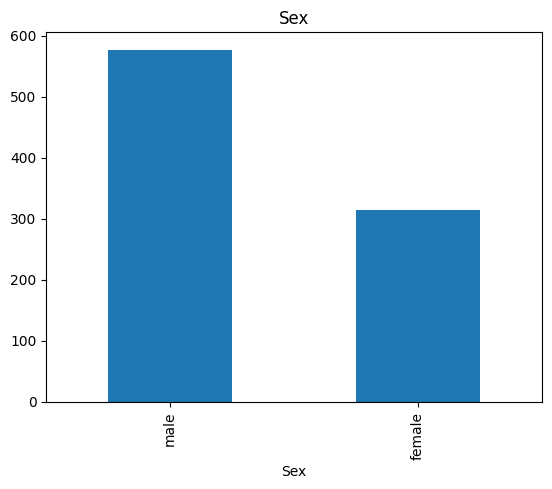

In [ ]:
feature = categorical_features[0]
count = data_train[feature].value_counts()
percent = 100*data_train[feature].value_counts(normalize=True)
df = pd.DataFrame({'jumlah sampel':count, 'persentase':percent.round(1)})
print(df)
count.plot(kind='bar', title=feature);

#### Distribusi Pelabuhan Keberangkatan

          jumlah sampel  persentase
Embarked                           
S                   644        72.4
C                   168        18.9
Q                    77         8.7


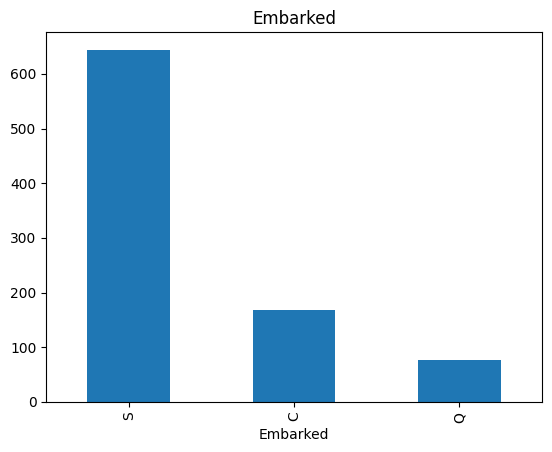

In [ ]:
feature = categorical_features[1]
count = data_train[feature].value_counts()
percent = 100*data_train[feature].value_counts(normalize=True)
df = pd.DataFrame({'jumlah sampel':count, 'persentase':percent.round(1)})
print(df)
count.plot(kind='bar', title=feature);

#### Histogram Fitur Numerik

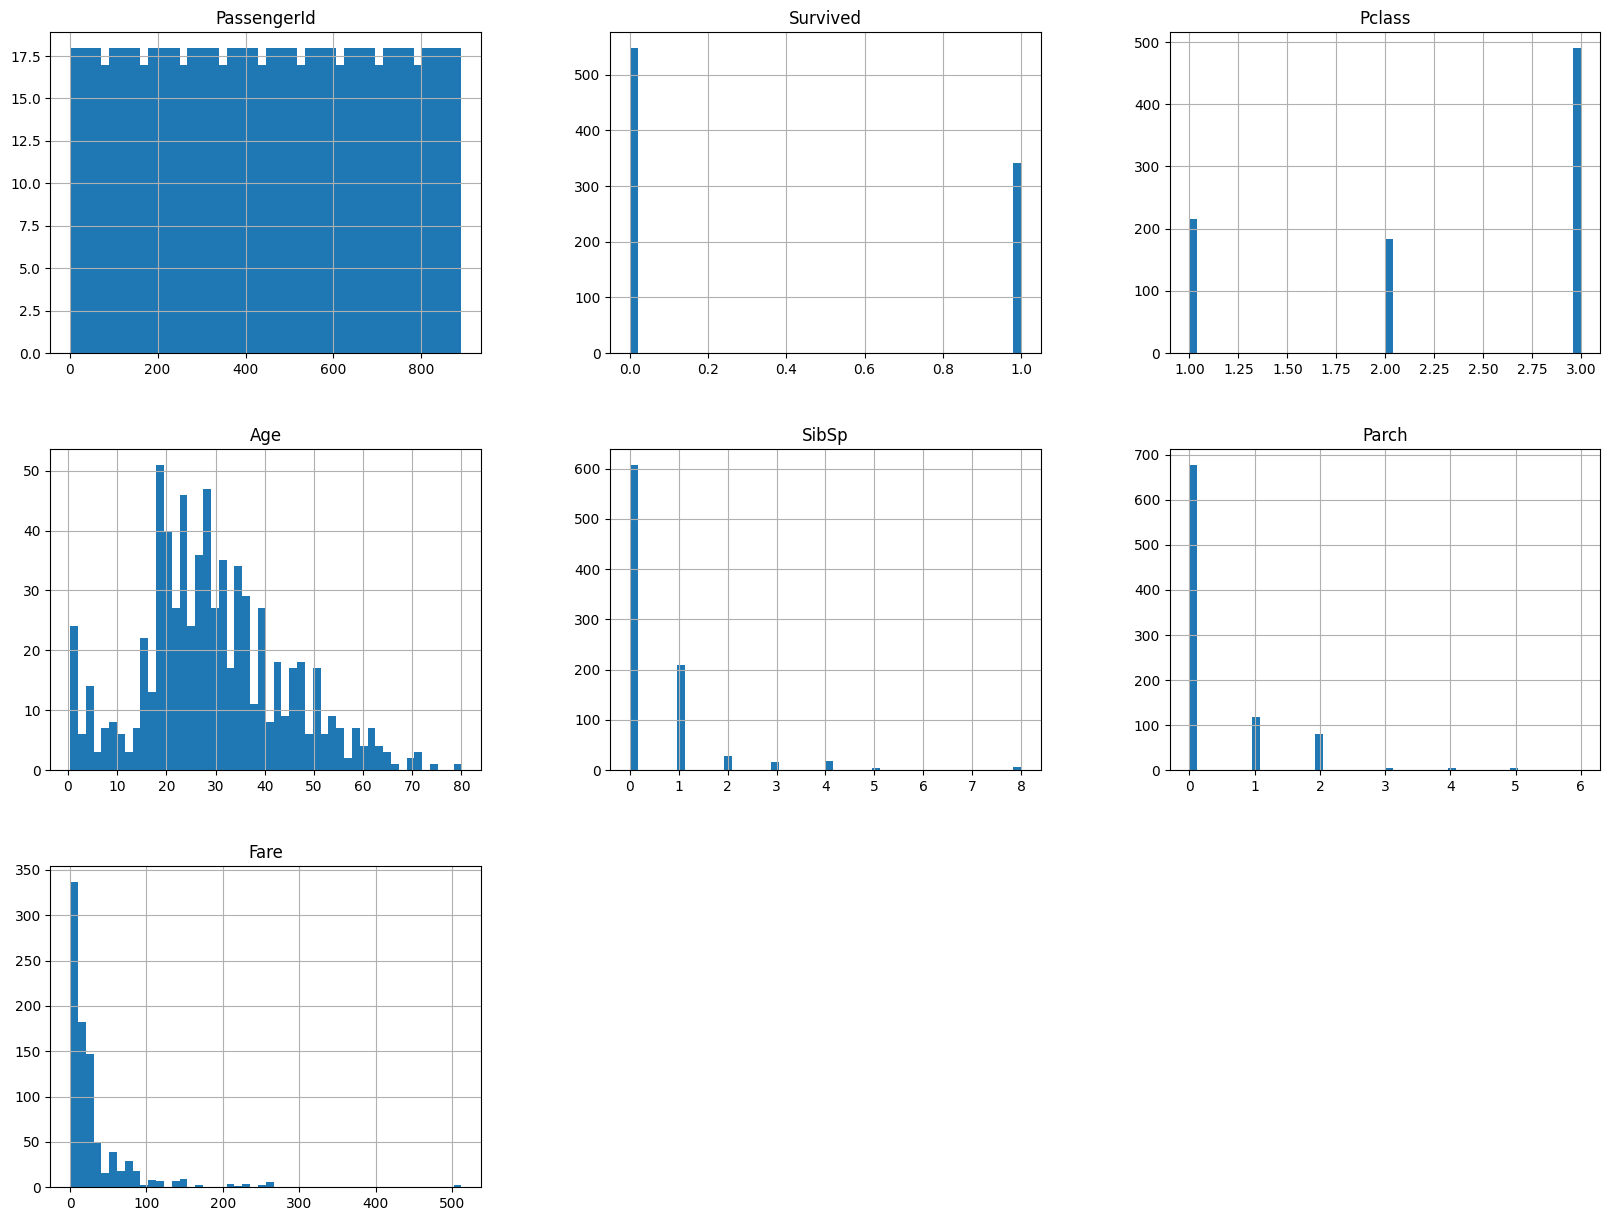

In [ ]:

data_train.hist(bins=50, figsize=(20,15))
plt.show()

### Multivariate Analysis

#### Melihat hubungan fitur dengan target (Survived).

/tmp/ipython-input-1181831508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=col, y="Survived", kind="bar", dodge=False, height = 4, aspect = 3,  data=data_train, palette="Set3")
/tmp/ipython-input-1181831508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=col, y="Survived", kind="bar", dodge=False, height = 4, aspect = 3,  data=data_train, palette="Set3")


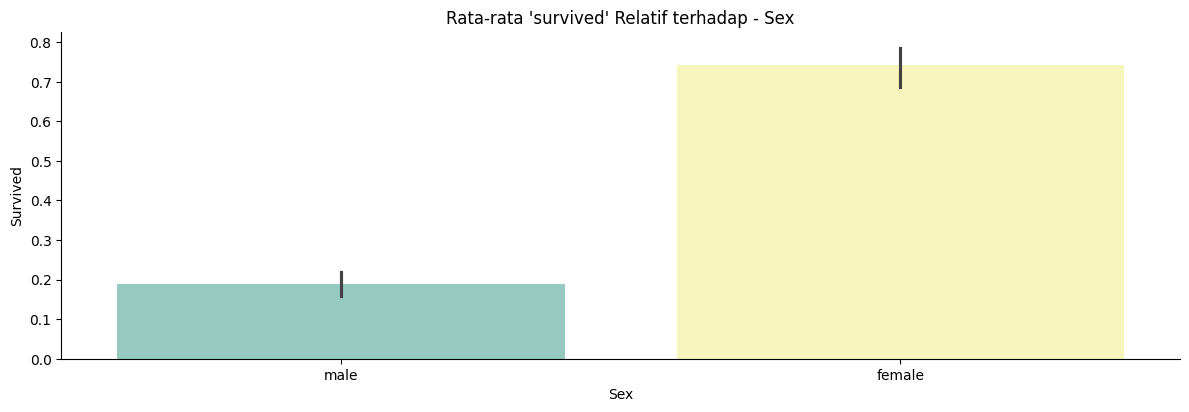

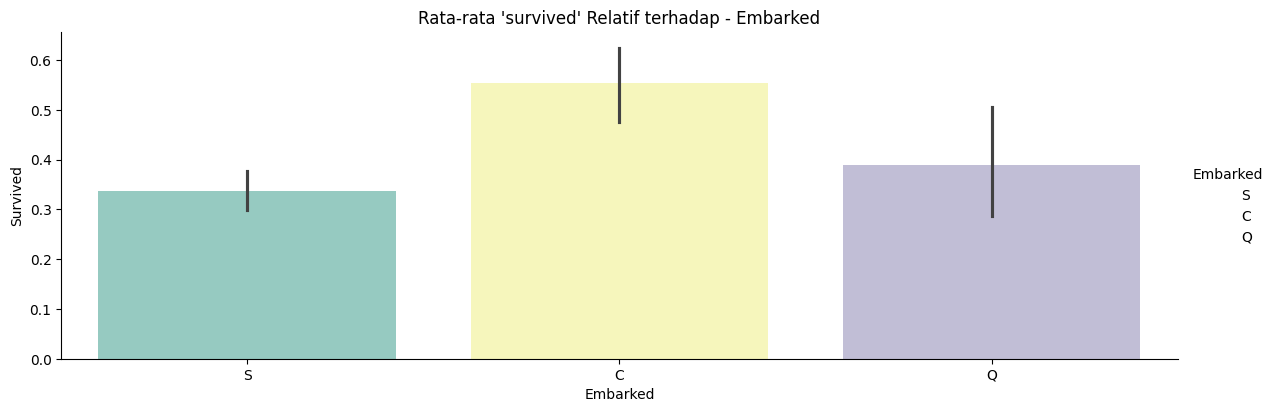

In [ ]:
cat_features = data_train.select_dtypes(include='object').columns.to_list()

for col in categorical_features:
  sns.catplot(x=col, y="Survived", kind="bar", dodge=False, height = 4, aspect = 3,  data=data_train, palette="Set3")
  plt.title("Rata-rata 'survived' Relatif terhadap - {}".format(col))

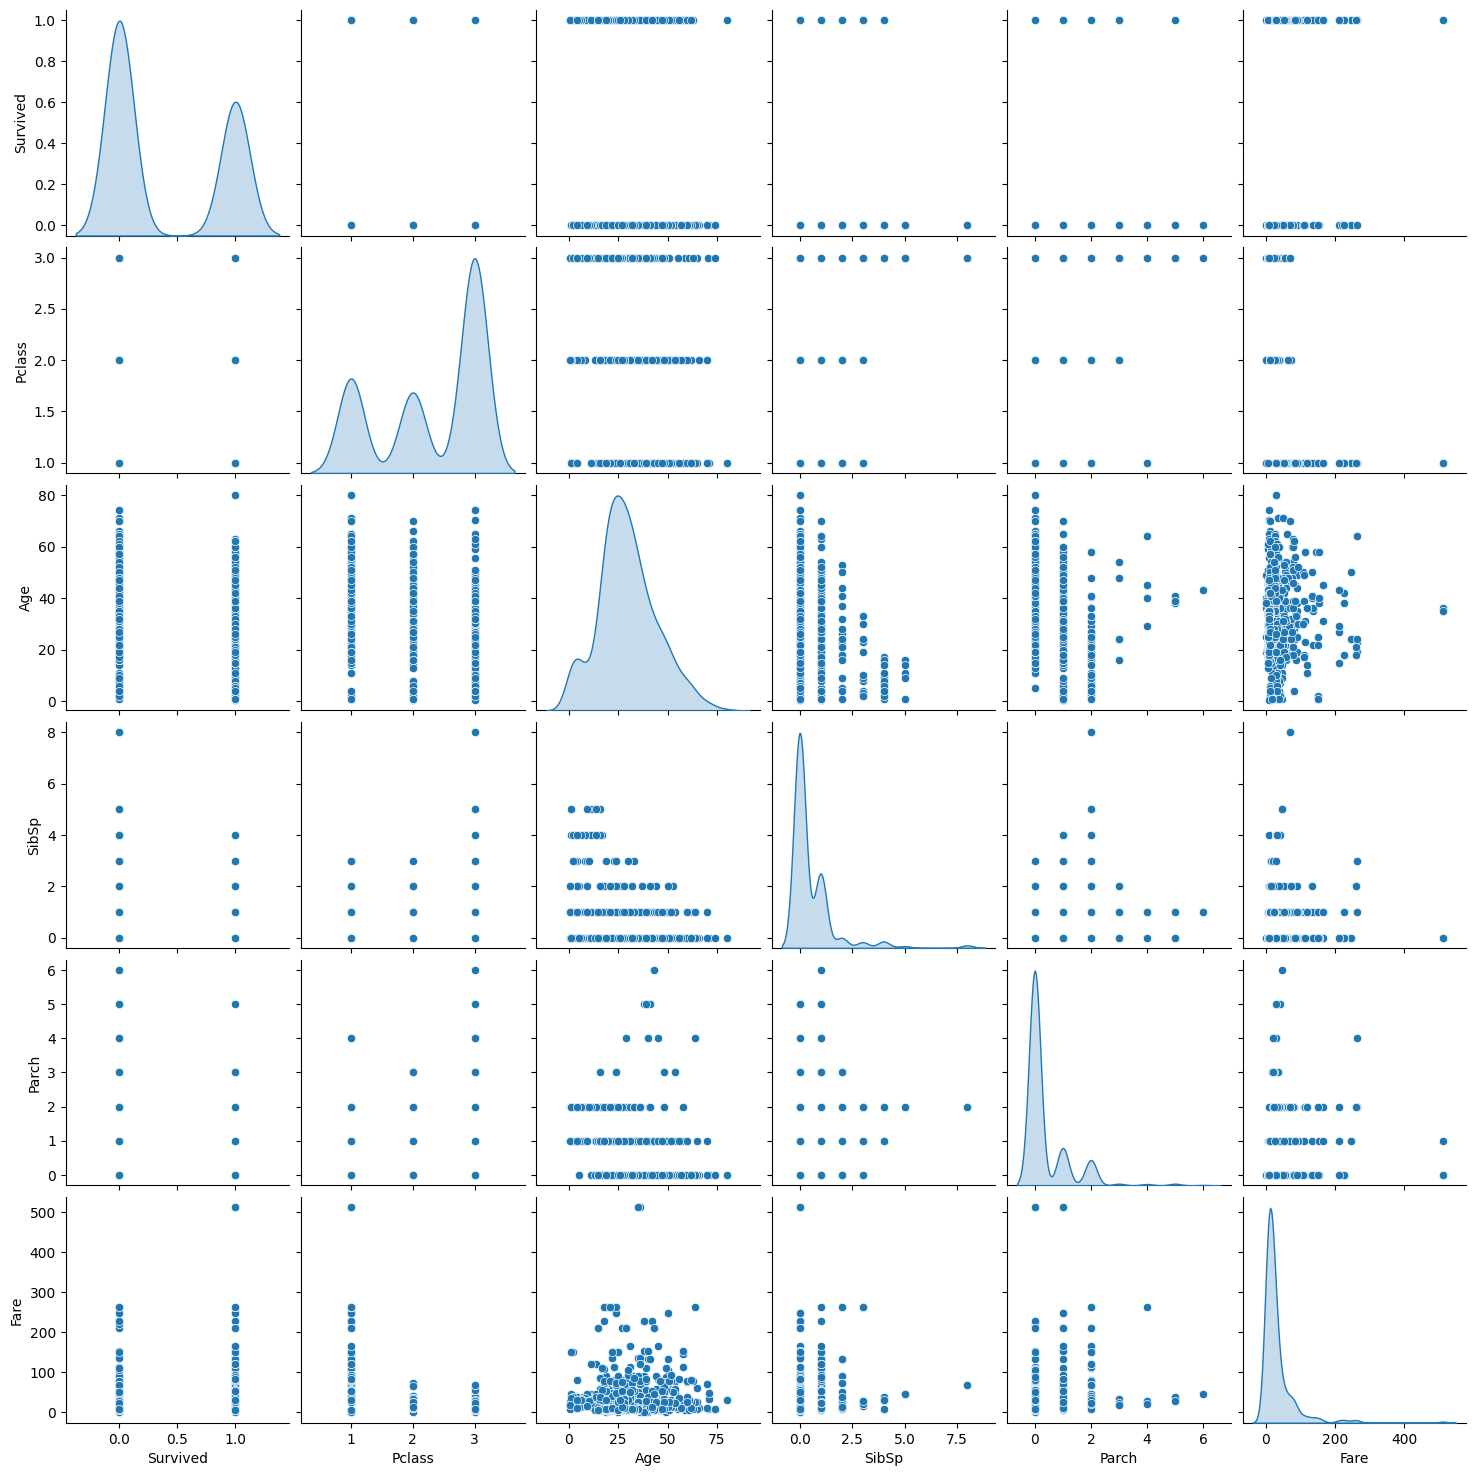

In [ ]:
# Observing the relationship between numeric features with the pairplot() function
sns.pairplot(data_train[numerical_features], diag_kind = 'kde')

Text(0.5, 1.0, 'Correlation Matrix untuk Fitur Numerik ')

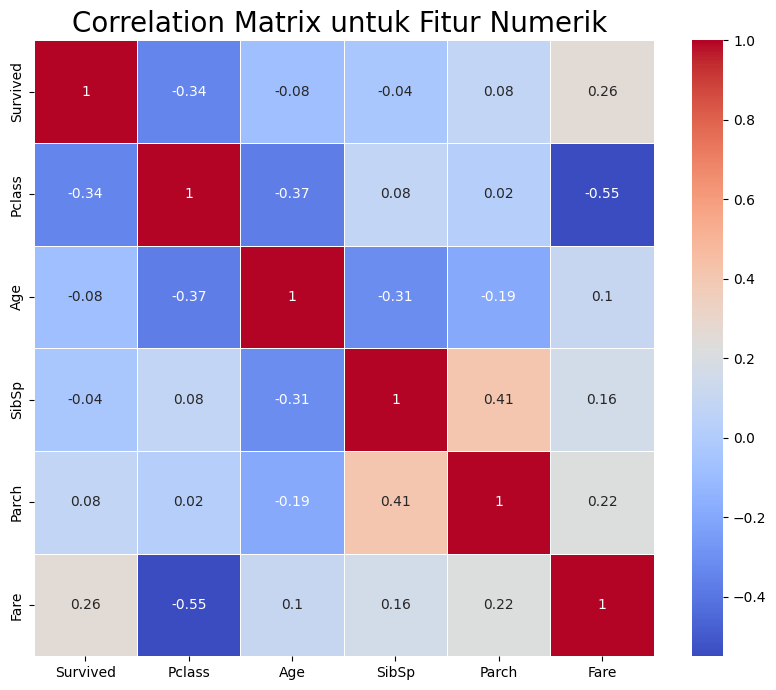

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = data_train[numerical_features].corr().round(2)

# To print the value in the box, use the not=True parameter
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, )
plt.title("Correlation Matrix untuk Fitur Numerik ", size=20)

# Data Preparation

## Handling Missing Value

In [ ]:
clean_df = data_train.dropna(subset=['Age', 'Embarked'])

## Menghapus Variabel Noise

In [ ]:
clean_df.drop(
    ['PassengerId', 'Name', 'Ticket', 'Cabin'],
    axis=1,
    inplace=True)

clean_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    object 
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Fare      712 non-null    float64
 7   Embarked  712 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 50.1+ KB


## Feature Encoding

In [ ]:
data_final = pd.concat([clean_df, pd.get_dummies(clean_df['Sex'], prefix='Sex').astype(int)],axis=1)
data_final = pd.concat([data_final, pd.get_dummies(data_final['Embarked'], prefix='Embarked').astype(int)],axis=1)
data_final.drop(['Sex','Embarked'], axis=1, inplace=True)
data_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    712 non-null    int64  
 1   Pclass      712 non-null    int64  
 2   Age         712 non-null    float64
 3   SibSp       712 non-null    int64  
 4   Parch       712 non-null    int64  
 5   Fare        712 non-null    float64
 6   Sex_female  712 non-null    int64  
 7   Sex_male    712 non-null    int64  
 8   Embarked_C  712 non-null    int64  
 9   Embarked_Q  712 non-null    int64  
 10  Embarked_S  712 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 66.8 KB


In [ ]:
data_final.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,1,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,1,35.0,1,0,53.1000,1,0,0,0,1
4,0,3,35.0,0,0,8.0500,0,1,0,0,1


## Handling Imbalanced Data

In [ ]:
X = data_final.drop(["Survived"],axis =1)
y = data_final["Survived"]
# Oversampling use RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Splitting Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.1,
    random_state=42
)

print("Train:", len(X_train))
print("Test :", len(X_test))

Train: 763
Test : 85


# Training Model Random Forest

In [ ]:
# Initialize RF and call the fit function to train the model
RF = RandomForestClassifier(class_weight='balanced', random_state=42)
RF.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

# Evaluation Model Random Forest

In [ ]:
y_pred_train = RF.predict(X_train)
y_pred_test  = RF.predict(X_test)

print("Accuracy Train:", accuracy_score(y_train, y_pred_train))
print("Accuracy Test :", accuracy_score(y_test, y_pred_test))


Accuracy Train: 0.9842726081258192
Accuracy Test : 0.9058823529411765


In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


Confusion Matrix:
[[38  7]
 [ 1 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90        45
           1       0.85      0.97      0.91        40

    accuracy                           0.91        85
   macro avg       0.91      0.91      0.91        85
weighted avg       0.91      0.91      0.91        85



# Prediction (Data Prediksi)

In [ ]:
data_pred = data_test.copy()
data_pred.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Data Preparation Data Prediksi

In [ ]:
#  Menangani missing value
data_pred['Age'] = data_pred['Age'].fillna(data_pred['Age'].median())
data_pred['Embarked'] = data_pred['Embarked'].fillna(data_pred['Embarked'].mode()[0])

# Feature Encoding untuk variabel kategorikal
data_pred = pd.concat([
    data_pred,
    pd.get_dummies(data_pred['Sex'], prefix='Sex'),
    pd.get_dummies(data_pred['Embarked'], prefix='Embarked')
], axis=1)

# Menghapus kolom asli yang sudah di-encode ('Sex' dan 'Embarked') dan kolom identitas ('PassengerId', 'Name', 'Ticket', 'Cabin')
data_pred = data_pred.drop(['Sex', 'Embarked', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Konversi kolom hasil dummies dari bool ke int
for col in ['Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']:
    data_pred[col] = data_pred[col].astype(int)

# Menyamakan kolom dengan data training, jika ada kolom yang tidak ada di data_pred, diisi 0
data_pred = data_pred.reindex(columns=X_train.columns, fill_value=0)

## Melakukan Prediksi

In [ ]:
data_test['prediction'] = RF.predict(data_pred)

# Simpan file Excel hanya dengan fitur + kolom prediksi
data_test_output = pd.concat([data_pred.reset_index(drop=True), data_test['prediction']], axis=1)
data_test_output.to_excel("hasil_Data_prediksi.xlsx", index=False)
data_test_output.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,prediction
0,3,34.5,0,0,7.8292,0,1,0,1,0,0
1,3,47.0,1,0,7.0000,1,0,0,0,1,0
2,2,62.0,0,0,9.6875,0,1,0,1,0,0
3,3,27.0,0,0,8.6625,0,1,0,0,1,1
4,3,22.0,1,1,12.2875,1,0,0,0,1,1


            Jumlah Data  Persentase (%)
prediction                             
0                   241           57.66
1                   177           42.34


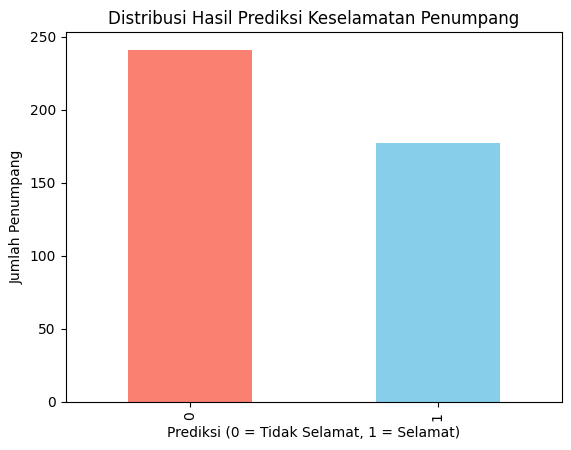

In [ ]:
distribution = data_test['prediction'].value_counts()
percentage = 100 * data_test['prediction'].value_counts(normalize=True)

df_distribution = pd.DataFrame({
    'Jumlah Data': distribution,
    'Persentase (%)': percentage.round(2)
})

print(df_distribution)

# Visualisasi distribusi prediksi
data_test['prediction'].value_counts().plot(
    kind='bar',
    title='Distribusi Hasil Prediksi Keselamatan Penumpang',
    color=['salmon','skyblue']
)
plt.xlabel('Prediksi (0 = Tidak Selamat, 1 = Selamat)')
plt.ylabel('Jumlah Penumpang')
plt.show()
